# Wheat Seeds Dataset — Basic Statistics & Visualization

**วิชา COS3302 — การบ้านครั้งที่ 3**

Notebook นี้ทำ Exploratory Data Analysis (EDA) ของชุดข้อมูล **Wheat Seeds** (UCI Machine Learning Repository)
ครอบคลุม 3 ส่วนตามโจทย์:

1. **ที่มาและความสำคัญ** ของชุดข้อมูล
2. **ค่าสถิติเบื้องต้น** (descriptive statistics)
3. **กราฟแบบต่าง ๆ** (visualization)

> รูปกราฟทุกใบถูกบันทึกในโฟลเดอร์ `charts/` เพื่อนำไปใส่สไลด์นำเสนอ
> (ข้อความบนกราฟใช้ภาษาอังกฤษเพื่อความคมชัดและเลี่ยงปัญหาฟอนต์ไทยใน matplotlib)


## 1. ที่มาและความสำคัญของชุดข้อมูล

| หัวข้อ | รายละเอียด |
|---|---|
| **ชื่อ** | Seeds Data Set (Wheat Seeds) |
| **แหล่ง** | UCI Machine Learning Repository — บริจาคปี 2012 |
| **ผู้จัดทำ** | M. Charytanowicz, J. Niewczas, P. Kulczycki, P.A. Kowalski, S. Łukasik, S. Żak — Institute of Agrophysics, Polish Academy of Sciences (เมือง Lublin ประเทศโปแลนด์) |
| **จำนวนข้อมูล** | 210 เมล็ด (rows) |
| **กลุ่ม (class)** | ข้าวสาลี 3 สายพันธุ์: **Kama (1), Rosa (2), Canadian (3)** พันธุ์ละ 70 เมล็ด (สมดุลพอดี) |
| **จำนวนตัวแปร** | 7 ตัวแปรเชิงตัวเลข + 1 ตัวแปรกลุ่ม |
| **วิธีวัด** | ถ่ายภาพเมล็ดด้วยเทคนิค **soft X-ray** แล้ววัดค่าเชิงเรขาคณิตด้วยแพ็กเกจ GRAINS |

**ทำไมชุดข้อมูลนี้ถึงสำคัญ / ถูกใช้บ่อย**

- **เกษตร & อุตสาหกรรมเมล็ดพันธุ์**: จำแนกสายพันธุ์ข้าวสาลีจากภาพ X-ray เป็นวิธี *ไม่ทำลายเมล็ด* (non-destructive) และถูกกว่าการใช้กล้องความละเอียดสูง → ใช้ตรวจคุณภาพ/คัดพันธุ์ได้เร็ว
- **Benchmark มาตรฐาน**: ข้อมูลสะอาด ไม่มีค่าหาย ขนาดกำลังดี คลาสสมดุล → เหมาะใช้สอน EDA, classification (kNN, SVM, Decision Tree) และ clustering (k-means)
- **ทุกตัวแปรเป็นตัวเลขต่อเนื่อง** ตีความเชิงกายภาพได้ชัด (ขนาด/รูปทรงของเมล็ด) เหมาะกับการอธิบายเชิงสถิติและกราฟ


## 2. Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pandas.plotting import parallel_coordinates
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"

CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

def save(fig, name):
    path = CHART_DIR / name
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    print("saved:", path)


## 3. โหลดข้อมูล & ตรวจโครงสร้าง

In [2]:
FEATURES = [
    "Area",                    # พื้นที่เมล็ด
    "Perimeter",               # เส้นรอบรูป
    "Compactness",             # ความกลม  C = 4*pi*A / P^2
    "Length of Kernel",        # ความยาวเมล็ด
    "Width of Kernel",         # ความกว้างเมล็ด
    "Asymmetry Coefficient",   # สัมประสิทธิ์ความไม่สมมาตร
    "Length of Kernel Groove", # ความยาวร่องกลางเมล็ด
]
COLS = FEATURES + ["Class"]

df = pd.read_csv("wheat-seeds.csv", header=None, names=COLS)

# แปลงรหัสคลาสเป็นชื่อสายพันธุ์ ช่วยให้กราฟอ่านง่าย
VARIETY = {1: "Kama", 2: "Rosa", 3: "Canadian"}
df["Variety"] = df["Class"].map(VARIETY)

print("Shape:", df.shape)
df.head()


Shape: (210, 9)


,Area,Perimeter,Compactness,Length of Kernel,Width of Kernel,Asymmetry Coefficient,Length of Kernel Groove,Class,Variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Area                     210 non-null    float64
 1   Perimeter                210 non-null    float64
 2   Compactness              210 non-null    float64
 3   Length of Kernel         210 non-null    float64
 4   Width of Kernel          210 non-null    float64
 5   Asymmetry Coefficient    210 non-null    float64
 6   Length of Kernel Groove  210 non-null    float64
 7   Class                    210 non-null    int64  
 8   Variety                  210 non-null    str    
dtypes: float64(7), int64(1), str(1)
memory usage: 14.9 KB


In [4]:
# ตรวจค่าหาย (missing values) และแถวซ้ำ
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())


Missing values per column:
Area                       0
Perimeter                  0
Compactness                0
Length of Kernel           0
Width of Kernel            0
Asymmetry Coefficient      0
Length of Kernel Groove    0
Class                      0
Variety                    0
dtype: int64

Duplicated rows: 0


In [5]:
# การกระจายของคลาส
class_counts = df["Variety"].value_counts().reindex(["Kama", "Rosa", "Canadian"])
print("Seeds per variety:")
print(class_counts)
print("\nProportion (%):")
print((class_counts / len(df) * 100).round(1))


Seeds per variety:
Variety
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64

Proportion (%):
Variety
Kama        33.3
Rosa        33.3
Canadian    33.3
Name: count, dtype: float64


## 4. ค่าสถิติเบื้องต้น (Descriptive Statistics)

In [6]:
# ตารางสรุปมาตรฐานของ pandas
df[FEATURES].describe().round(3)


,Area,Perimeter,Compactness,Length of Kernel,Width of Kernel,Asymmetry Coefficient,Length of Kernel Groove
count,210.000,210.000,210.000,210.000,210.000,210.000,210.000
mean,14.848,14.559,0.871,5.629,3.259,3.700,5.408
std,2.910,1.306,0.024,0.443,0.378,1.504,0.491
min,10.590,12.410,0.808,4.899,2.630,0.765,4.519
25%,12.270,13.450,0.857,5.262,2.944,2.562,5.045
50%,14.355,14.320,0.873,5.524,3.237,3.599,5.223
75%,17.305,15.715,0.888,5.980,3.562,4.769,5.877
max,21.180,17.250,0.918,6.675,4.033,8.456,6.550


In [7]:
# ตารางสรุปแบบขยาย: range, variance, std, median, mean, mode, skewness, kurtosis, IQR
def summary_stats(frame, features=FEATURES):
    rows = []
    for c in features:
        s = frame[c]
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        rows.append({
            "feature": c,
            "min": round(s.min(), 3),
            "max": round(s.max(), 3),
            "range": round(s.max() - s.min(), 3),
            "mean": round(s.mean(), 3),
            "median": round(s.median(), 3),
            "mode": round(s.mode().iloc[0], 3),
            "std": round(s.std(), 3),
            "var": round(s.var(), 3),
            "IQR": round(q3 - q1, 3),
            "skew": round(s.skew(), 3),
            "kurtosis": round(s.kurtosis(), 3),
        })
    return pd.DataFrame(rows)

summary_tbl = summary_stats(df)
summary_tbl


,feature,min,max,range,mean,median,mode,std,var,IQR,skew,kurtosis
0,Area,10.590,21.180,10.590,14.848,14.355,11.230,2.910,8.466,5.035,0.400,-1.084
1,Perimeter,12.410,17.250,4.840,14.559,14.320,13.470,1.306,1.706,2.265,0.387,-1.107
2,Compactness,0.808,0.918,0.110,0.871,0.873,0.882,0.024,0.001,0.031,-0.538,-0.140
3,Length of Kernel,4.899,6.675,1.776,5.629,5.524,5.236,0.443,0.196,0.718,0.525,-0.786
4,Width of Kernel,2.630,4.033,1.403,3.259,3.237,3.026,0.378,0.143,0.618,0.134,-1.098
5,Asymmetry Coefficient,0.765,8.456,7.691,3.700,3.599,2.129,1.504,2.261,2.207,0.402,-0.067
6,Length of Kernel Groove,4.519,6.550,2.031,5.408,5.223,5.001,0.491,0.242,0.832,0.562,-0.841


In [8]:
# ค่าเฉลี่ยของแต่ละ feature แยกตามสายพันธุ์
mean_by_variety = (df.groupby("Variety")[FEATURES].mean()
                     .reindex(["Kama", "Rosa", "Canadian"]).round(3))
mean_by_variety.T   # transpose ให้ feature เป็นแถว อ่านง่าย


Variety,Kama,Rosa,Canadian
Area,14.334,18.334,11.874
Perimeter,14.294,16.136,13.248
Compactness,0.880,0.884,0.849
Length of Kernel,5.508,6.148,5.230
Width of Kernel,3.245,3.677,2.854
Asymmetry Coefficient,2.667,3.645,4.788
Length of Kernel Groove,5.087,6.021,5.116


In [9]:
# ส่วนเบี่ยงเบนมาตรฐานแยกตามสายพันธุ์
df.groupby("Variety")[FEATURES].std().reindex(["Kama", "Rosa", "Canadian"]).round(3).T


Variety,Kama,Rosa,Canadian
Area,1.216,1.439,0.723
Perimeter,0.577,0.617,0.340
Compactness,0.016,0.016,0.022
Length of Kernel,0.232,0.268,0.138
Width of Kernel,0.178,0.186,0.148
Asymmetry Coefficient,1.174,1.182,1.336
Length of Kernel Groove,0.264,0.254,0.162


In [10]:
# ตรวจ outlier ด้วยกฎ IQR (1.5 * IQR)
def iqr_outliers(frame, features=FEATURES):
    rows = []
    for c in features:
        s = frame[c]
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (s < lo) | (s > hi)
        rows.append({"feature": c, "lower_bound": round(lo, 3),
                     "upper_bound": round(hi, 3), "n_outliers": int(mask.sum())})
    return pd.DataFrame(rows)

outlier_tbl = iqr_outliers(df)
print("IQR-rule outliers (whole dataset):")
print(outlier_tbl.to_string(index=False))
print("\nTotal outliers:", outlier_tbl["n_outliers"].sum(), "of", len(df) * len(FEATURES), "values")


IQR-rule outliers (whole dataset):
                feature  lower_bound  upper_bound  n_outliers
                   Area        4.717       24.858           0
              Perimeter       10.052       19.112           0
            Compactness        0.811        0.934           3
       Length of Kernel        4.186        7.056           0
        Width of Kernel        2.017        4.488           0
  Asymmetry Coefficient       -0.749        8.080           2
Length of Kernel Groove        3.797        7.125           0

Total outliers: 5 of 1470 values


In [11]:
# ตารางสหสัมพันธ์ (correlation matrix)
corr = df[FEATURES].corr().round(3)
corr


,Area,Perimeter,Compactness,Length of Kernel,Width of Kernel,Asymmetry Coefficient,Length of Kernel Groove
Area,1.000,0.994,0.608,0.950,0.971,-0.230,0.864
Perimeter,0.994,1.000,0.529,0.972,0.945,-0.217,0.891
Compactness,0.608,0.529,1.000,0.368,0.762,-0.331,0.227
Length of Kernel,0.950,0.972,0.368,1.000,0.860,-0.172,0.933
Width of Kernel,0.971,0.945,0.762,0.860,1.000,-0.258,0.749
Asymmetry Coefficient,-0.230,-0.217,-0.331,-0.172,-0.258,1.000,-0.011
Length of Kernel Groove,0.864,0.891,0.227,0.933,0.749,-0.011,1.000


## 5. กราฟแบบต่าง ๆ (Visualization)

### 5.1 การกระจายจำนวนเมล็ดต่อสายพันธุ์ (Bar chart)

saved: charts/01_class_distribution.png


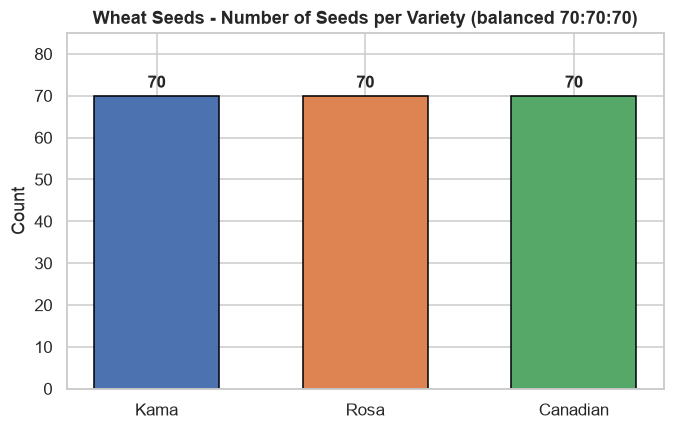

In [12]:
palette = {"Kama": "#4C72B0", "Rosa": "#DD8452", "Canadian": "#55A868"}

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(class_counts.index, class_counts.values,
              color=list(palette.values()), edgecolor="black", width=0.6)
ax.bar_label(bars, padding=3, fontweight="bold")
ax.set_ylabel("Count")
ax.set_title("Wheat Seeds - Number of Seeds per Variety (balanced 70:70:70)")
ax.set_ylim(0, 85)
save(fig, "01_class_distribution.png")
plt.show()


### 5.2 การแจกแจงของแต่ละตัวแปร (Histogram grid — ภาพรวม)

saved: charts/02_hist_overall.png


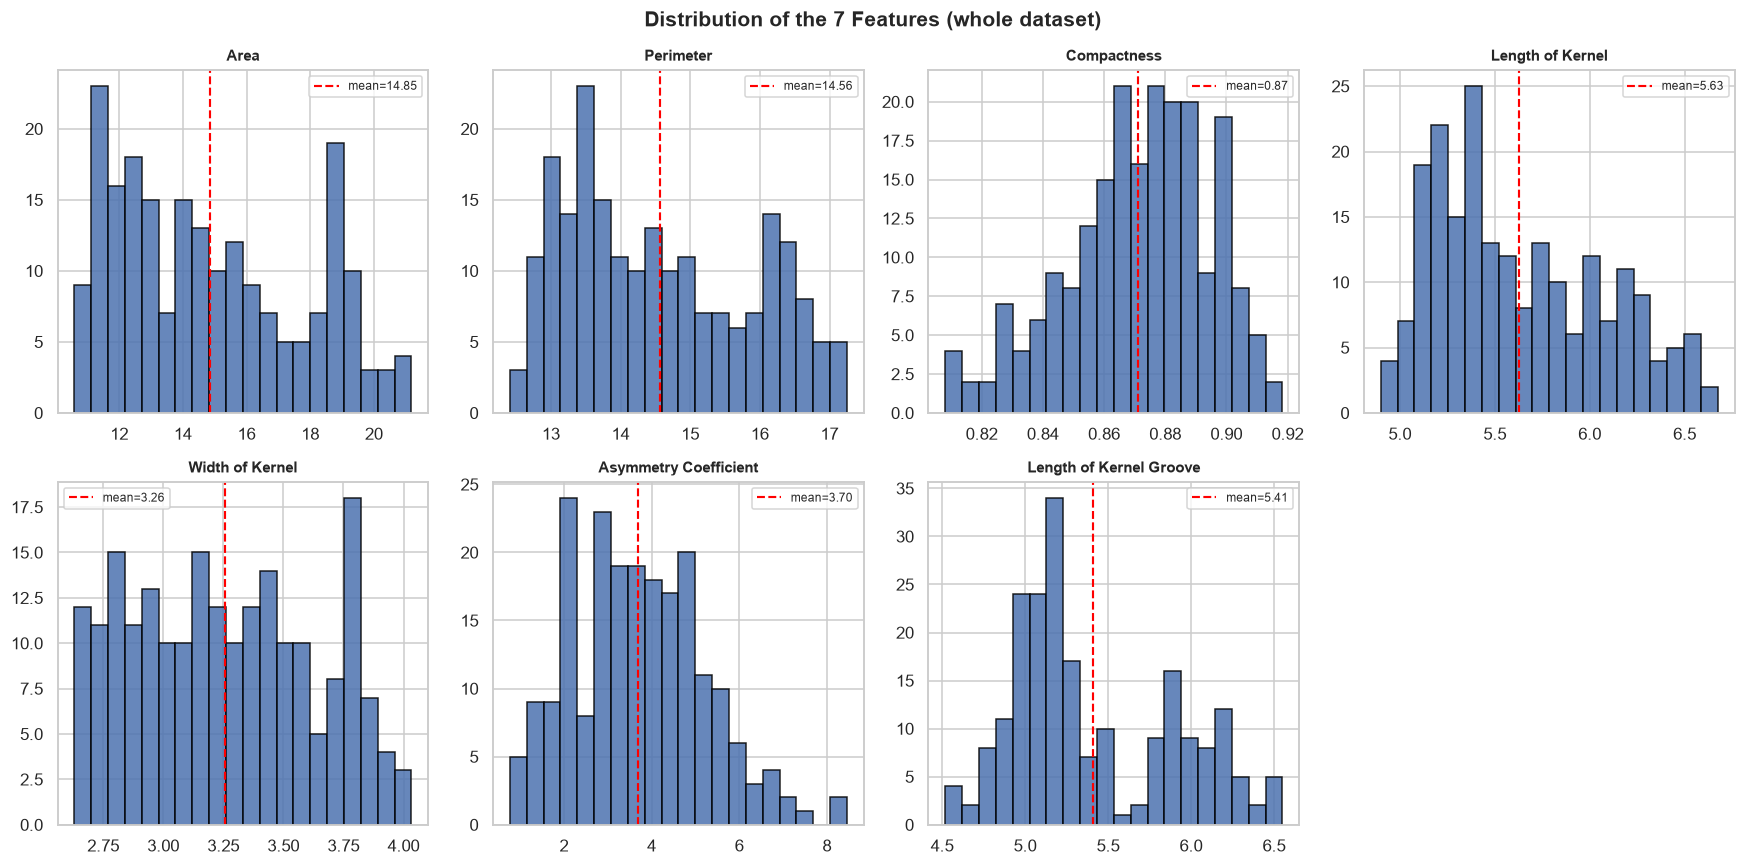

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, c in zip(axes.flat, FEATURES):
    ax.hist(df[c], bins=20, color="#4C72B0", edgecolor="black", alpha=0.85)
    ax.axvline(df[c].mean(), color="red", linestyle="--", linewidth=1.4,
               label=f"mean={df[c].mean():.2f}")
    ax.set_title(c, fontsize=10)
    ax.legend(fontsize=8)
axes.flat[-1].axis("off")
fig.suptitle("Distribution of the 7 Features (whole dataset)", fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "02_hist_overall.png")
plt.show()


### 5.3 Histogram แยกตามสายพันธุ์ (ดูความสามารถในการแยกกลุ่ม)

saved: charts/03_hist_by_variety.png


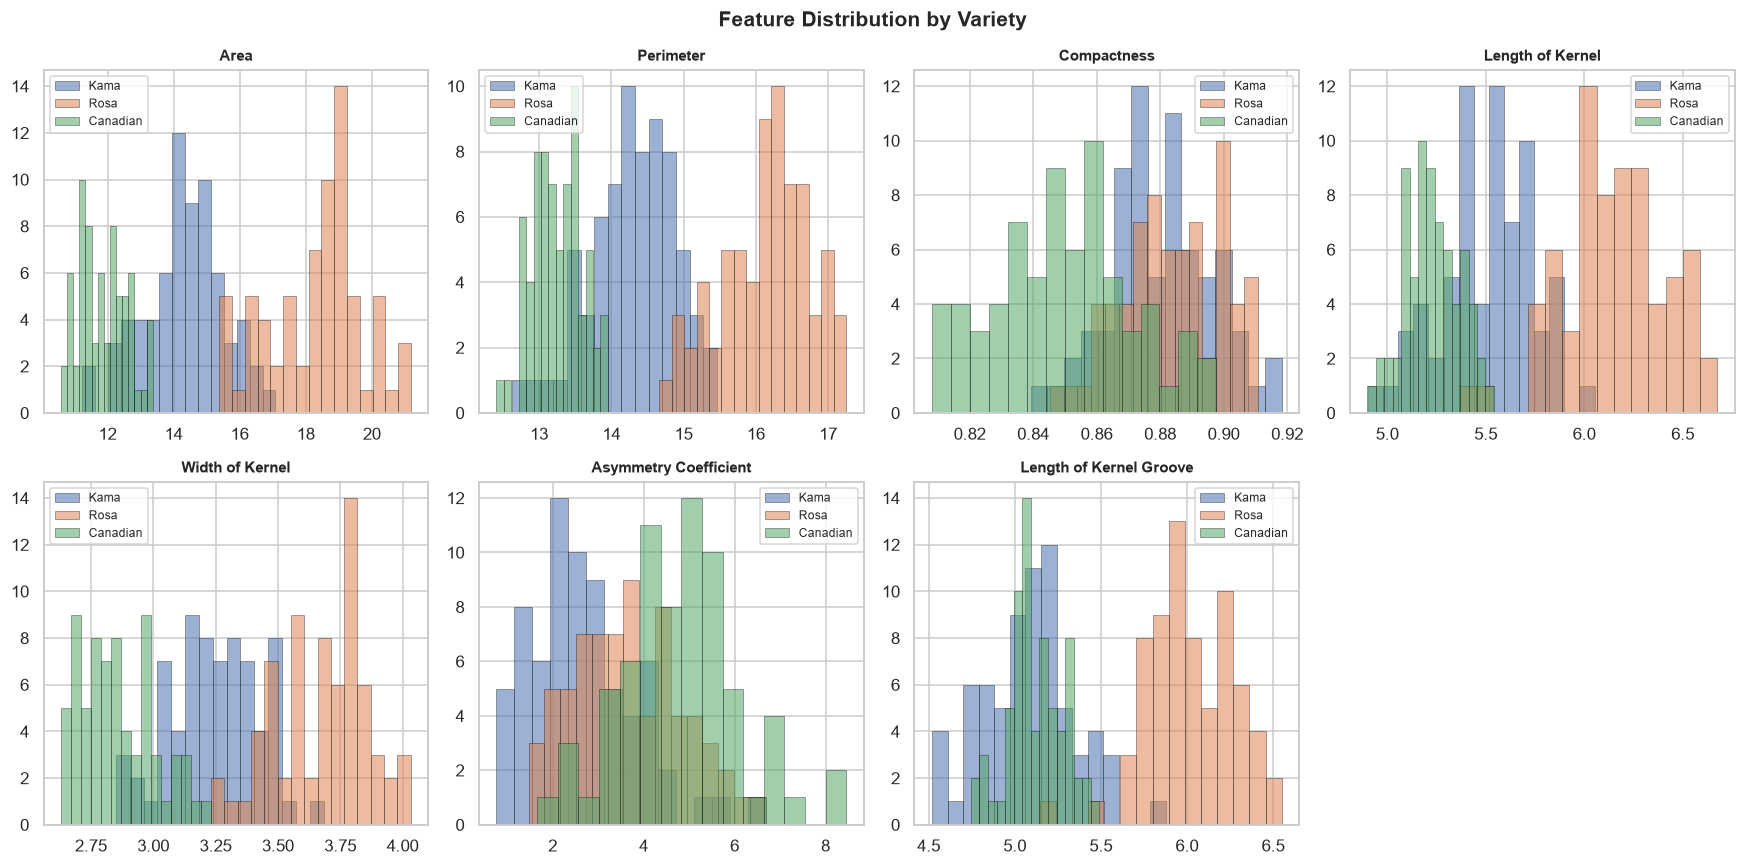

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, c in zip(axes.flat, FEATURES):
    for v in ["Kama", "Rosa", "Canadian"]:
        ax.hist(df.loc[df.Variety == v, c], bins=15, alpha=0.55,
                label=v, color=palette[v], edgecolor="black", linewidth=0.4)
    ax.set_title(c, fontsize=10)
    ax.legend(fontsize=8)
axes.flat[-1].axis("off")
fig.suptitle("Feature Distribution by Variety", fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "03_hist_by_variety.png")
plt.show()


### 5.4 Boxplot แยกตามสายพันธุ์ (สรุป 5 ค่า + outlier)

saved: charts/04_box_by_variety.png


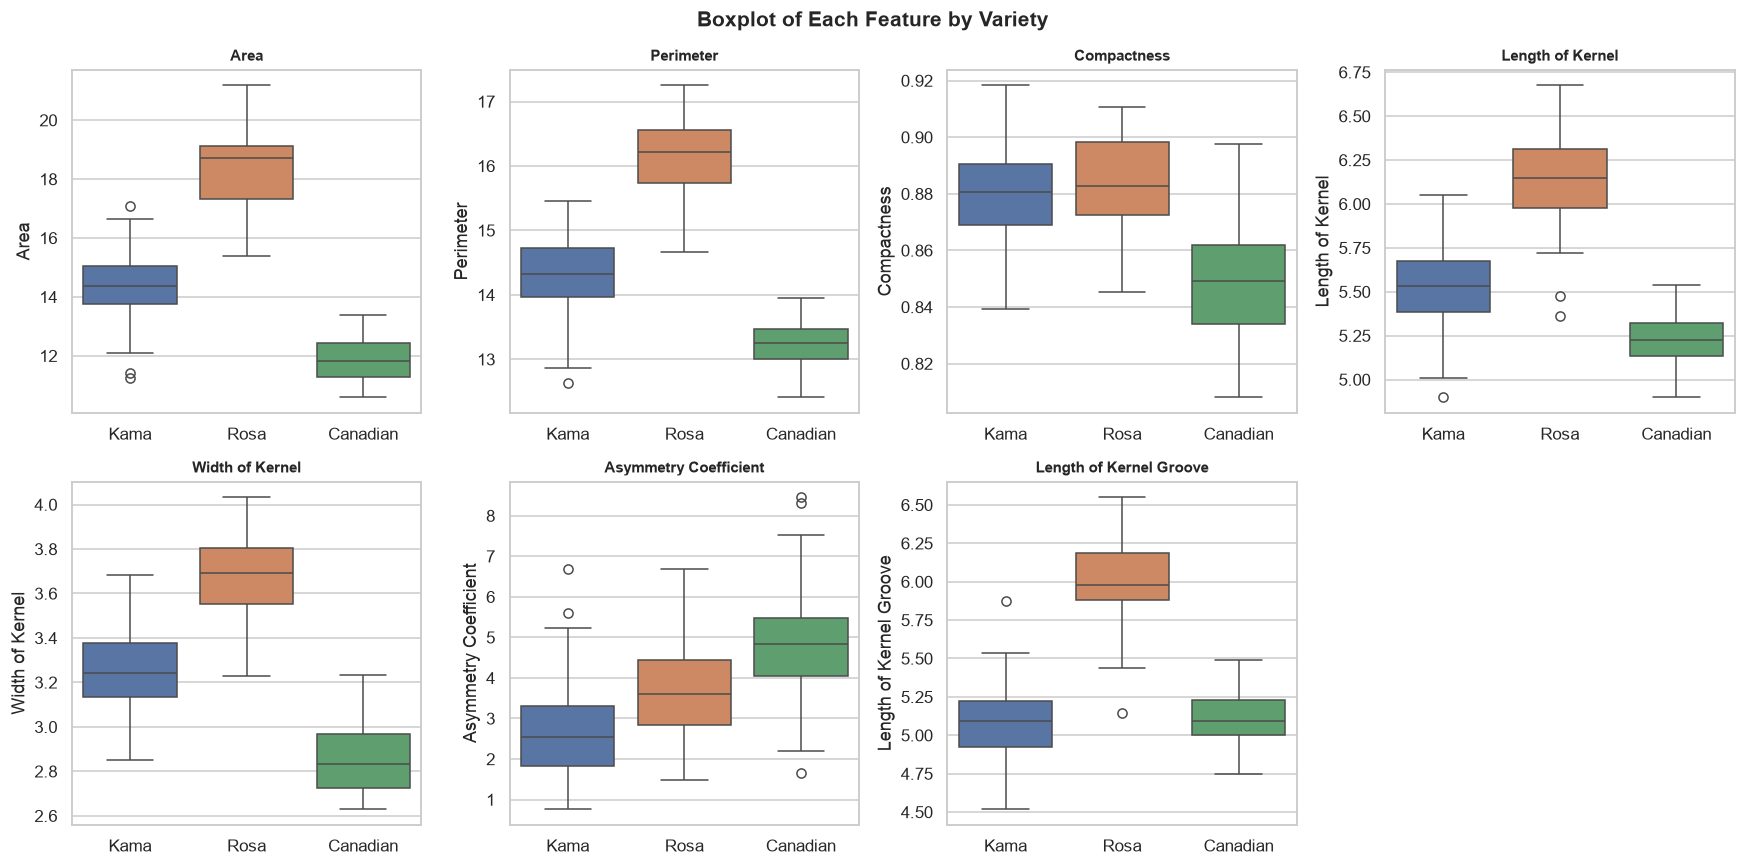

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, c in zip(axes.flat, FEATURES):
    sns.boxplot(data=df, x="Variety", y=c, order=["Kama", "Rosa", "Canadian"],
                hue="Variety", palette=palette, legend=False, ax=ax)
    ax.set_title(c, fontsize=10)
    ax.set_xlabel("")
axes.flat[-1].axis("off")
fig.suptitle("Boxplot of Each Feature by Variety", fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "04_box_by_variety.png")
plt.show()


### 5.5 Violin plot — รูปทรงการแจกแจง (feature เด่น 4 ตัว)

saved: charts/05_violin_top4.png


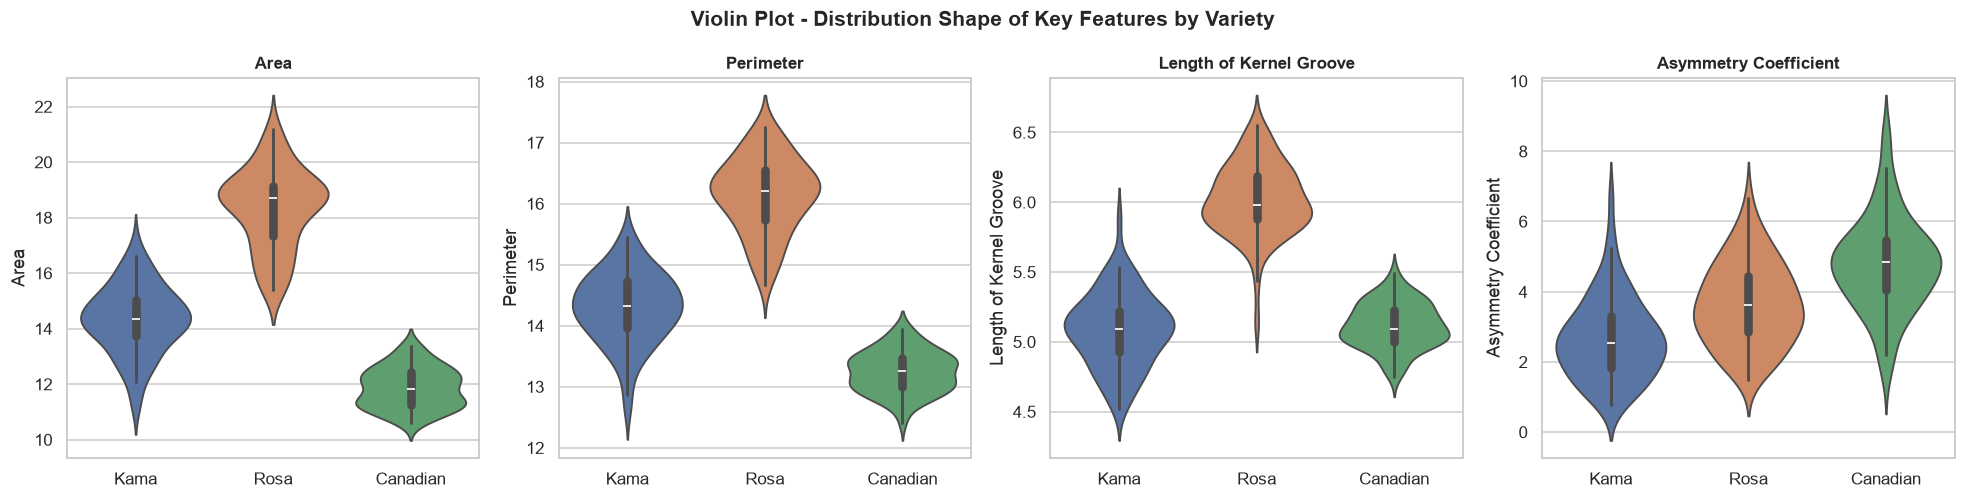

In [16]:
top4 = ["Area", "Perimeter", "Length of Kernel Groove", "Asymmetry Coefficient"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
for ax, c in zip(axes, top4):
    sns.violinplot(data=df, x="Variety", y=c, order=["Kama", "Rosa", "Canadian"],
                   hue="Variety", palette=palette, legend=False, ax=ax, inner="box")
    ax.set_title(c, fontsize=11)
    ax.set_xlabel("")
fig.suptitle("Violin Plot - Distribution Shape of Key Features by Variety",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "05_violin_top4.png")
plt.show()


### 5.6 Correlation heatmap

saved: charts/06_correlation_heatmap.png


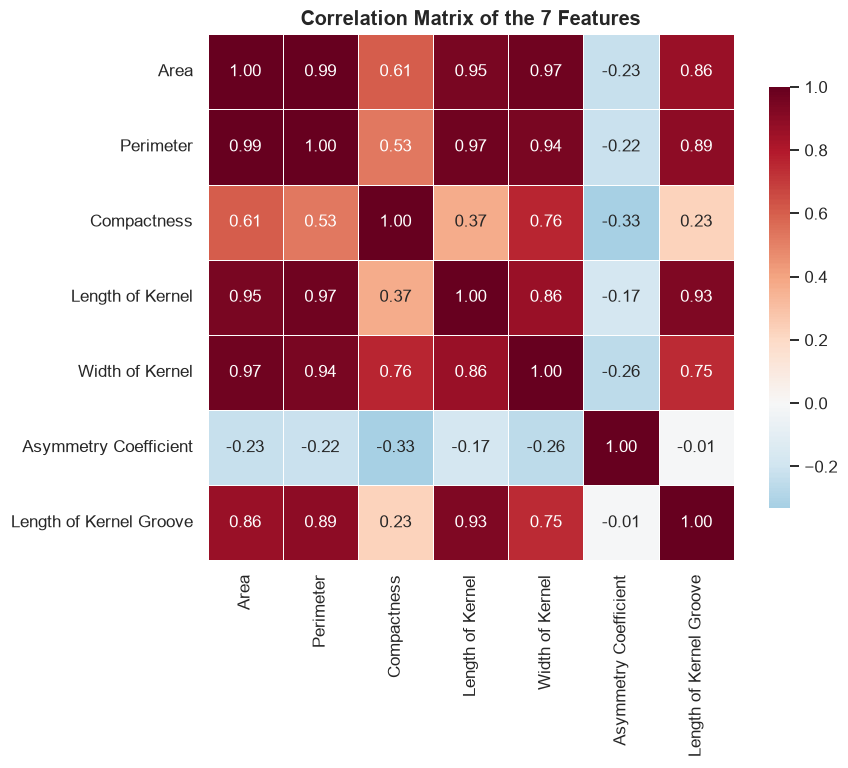

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Matrix of the 7 Features", fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "06_correlation_heatmap.png")
plt.show()


### 5.7 Pairplot — ความสัมพันธ์ทุกคู่ตัวแปร แยกสี

saved: charts/07_pairplot.png


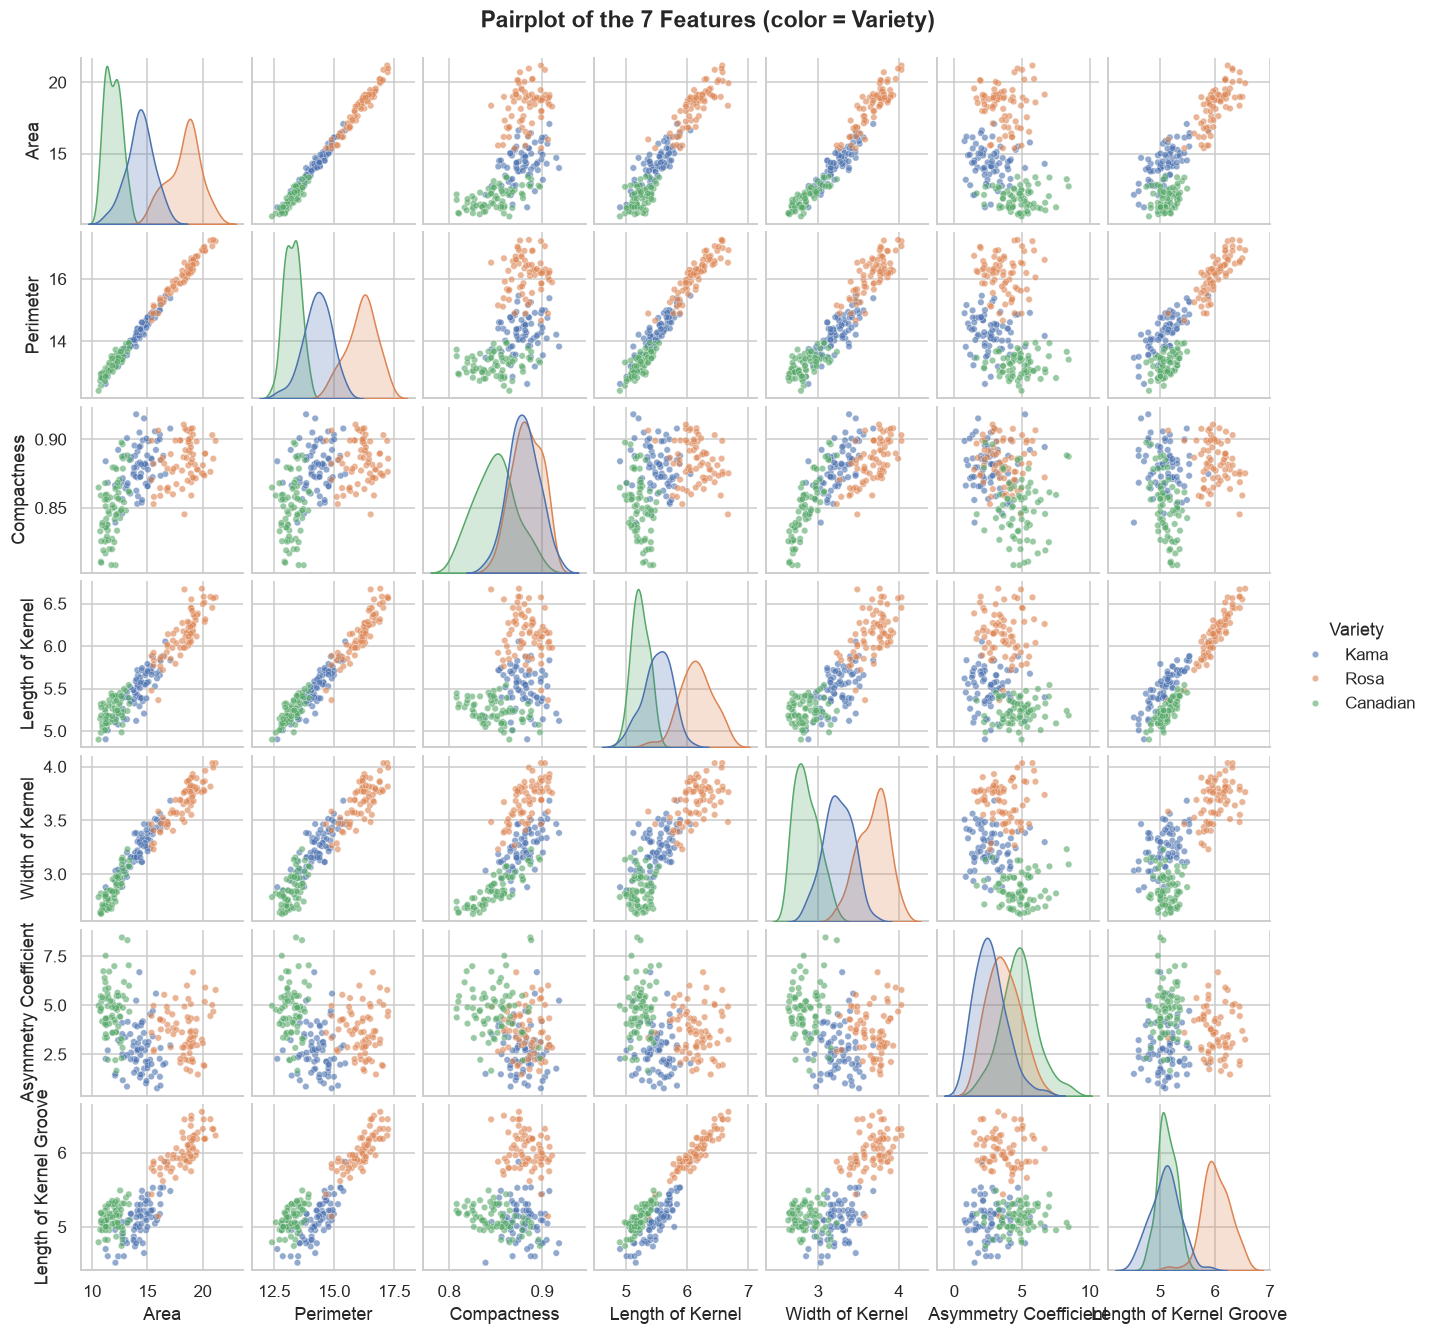

In [18]:
g = sns.pairplot(df[FEATURES + ["Variety"]], hue="Variety",
                 palette=palette, diag_kind="kde", height=1.7,
                 plot_kws=dict(s=18, alpha=0.6, edgecolor="white", linewidth=0.3))
g.fig.suptitle("Pairplot of the 7 Features (color = Variety)",
               y=1.02, fontsize=15, fontweight="bold")
save(g.fig, "07_pairplot.png")
plt.show()


### 5.8 Scatter — คู่ตัวแปรที่แยกสายพันธุ์ได้ชัด

saved: charts/08_scatter_pairs.png


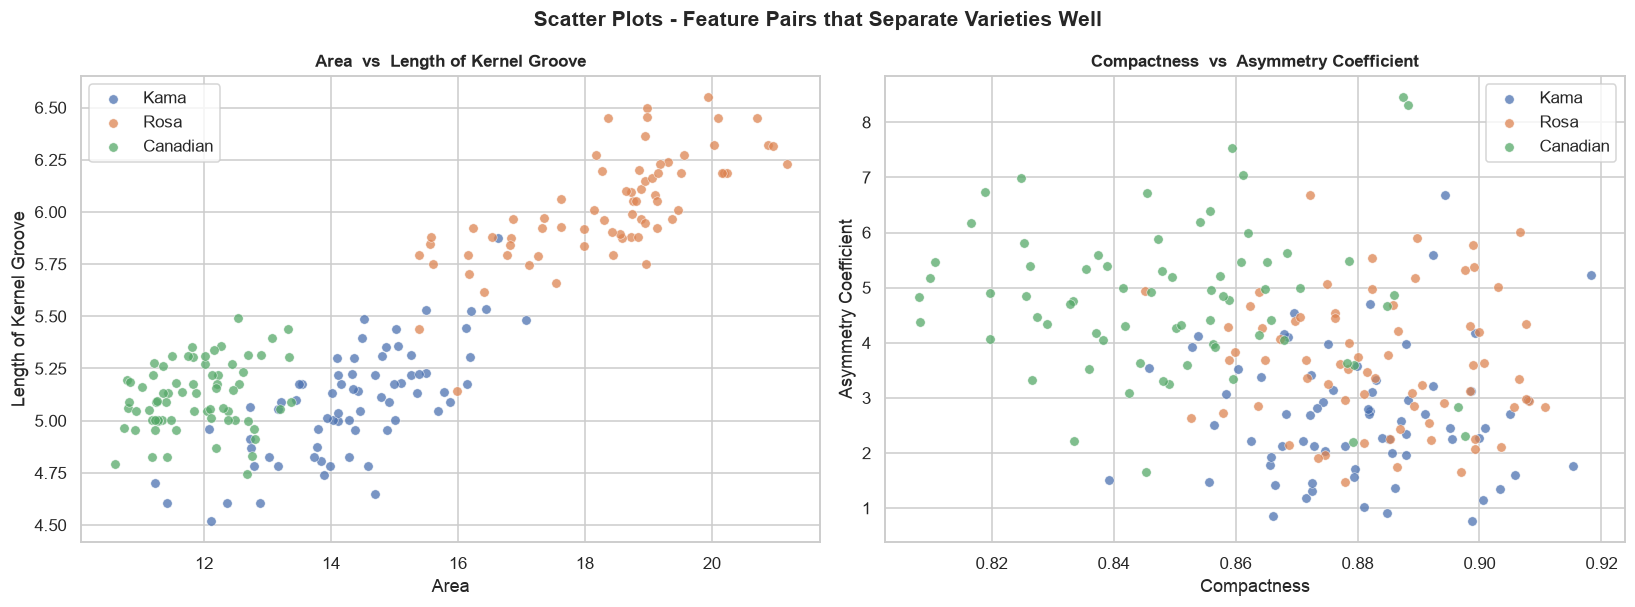

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
pairs = [("Area", "Length of Kernel Groove"), ("Compactness", "Asymmetry Coefficient")]
for ax, (x, y) in zip(axes, pairs):
    for v in ["Kama", "Rosa", "Canadian"]:
        sub = df[df.Variety == v]
        ax.scatter(sub[x], sub[y], label=v, color=palette[v], s=38,
                   alpha=0.75, edgecolor="white", linewidth=0.4)
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f"{x}  vs  {y}", fontsize=11)
    ax.legend()
fig.suptitle("Scatter Plots - Feature Pairs that Separate Varieties Well",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "08_scatter_pairs.png")
plt.show()


### 5.9 Parallel coordinates — โปรไฟล์หลายมิติของ 3 สายพันธุ์

saved: charts/09_parallel_coordinates.png


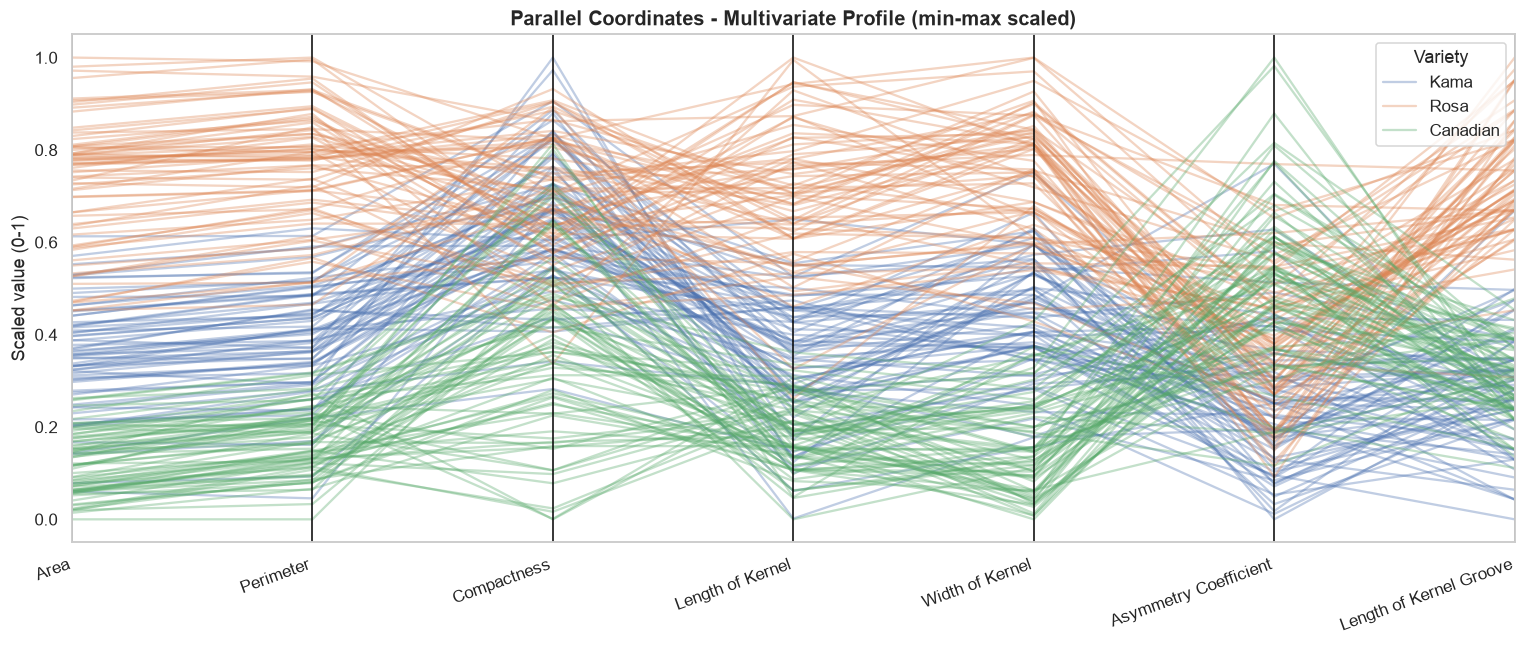

In [20]:
# ปรับ scale แต่ละ feature เป็นช่วง 0-1 (min-max) เพื่อเทียบรูปทรงได้
df_scaled = df.copy()
for c in FEATURES:
    df_scaled[c] = (df[c] - df[c].min()) / (df[c].max() - df[c].min())

fig, ax = plt.subplots(figsize=(14, 6))
parallel_coordinates(df_scaled[FEATURES + ["Variety"]], "Variety",
                     color=list(palette.values()), alpha=0.35, ax=ax)
ax.set_title("Parallel Coordinates - Multivariate Profile (min-max scaled)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Scaled value (0-1)")
plt.xticks(rotation=20, ha="right")
ax.legend(title="Variety", loc="upper right")
fig.tight_layout()
save(fig, "09_parallel_coordinates.png")
plt.show()


### 5.10 กราฟแท่งเปรียบเทียบค่าเฉลี่ยรายสายพันธุ์ (normalized)

saved: charts/10_mean_comparison.png


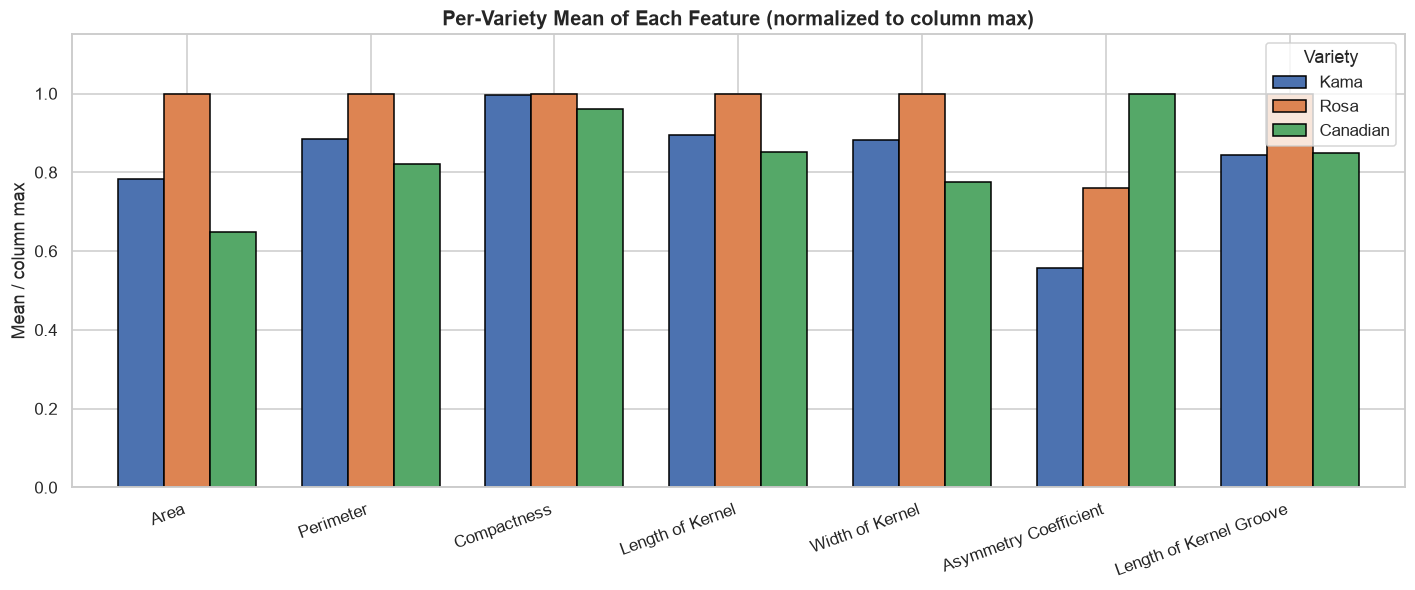

In [21]:
norm_mean = mean_by_variety / mean_by_variety.max()
fig, ax = plt.subplots(figsize=(13, 5.5))
norm_mean.T.plot(kind="bar", ax=ax, color=list(palette.values()),
                 edgecolor="black", width=0.75)
ax.set_ylabel("Mean / column max")
ax.set_title("Per-Variety Mean of Each Feature (normalized to column max)",
             fontsize=13, fontweight="bold")
ax.legend(title="Variety")
plt.xticks(rotation=20, ha="right")
ax.set_ylim(0, 1.15)
fig.tight_layout()
save(fig, "10_mean_comparison.png")
plt.show()


## 6. สรุปข้อค้นพบ (Key Findings)

1. **ข้อมูลสะอาดพร้อมใช้** — 210 แถว, ไม่มีค่าหาย, ไม่มีแถวซ้ำ, คลาสสมดุล 70:70:70
2. **Rosa เมล็ดใหญ่ที่สุด** ทุกมิติ (Area, Perimeter, Length, Width) ส่วน **Canadian เล็กที่สุด** — Kama อยู่ตรงกลาง
3. **Compactness** ของ Rosa/Kama สูงกว่า Canadian (เมล็ดกลมกว่า) ส่วน **Asymmetry Coefficient** ของ Canadian สูงสุด (เบี้ยวกว่า)
4. **สหสัมพันธ์สูงมาก** ระหว่าง Area–Perimeter–Length–Width (r > 0.86) เพราะเป็นมิติ "ขนาด" เดียวกัน → เกิด multicollinearity ถ้าจะทำโมเดลเชิงเส้น
5. **Asymmetry Coefficient** สหสัมพันธ์ต่ำ/ติดลบกับตัวอื่น → ให้ข้อมูลเสริมที่เป็นอิสระ
6. คู่ตัวแปร **Area × Length of Kernel Groove** แยก 3 สายพันธุ์ได้เกือบสมบูรณ์ด้วยตาเปล่า → เหมาะกับงาน classification/clustering
7. Outlier ตามกฎ IQR มีเพียง 5 จุดจาก 1,470 ค่า (ที่ Compactness และ Asymmetry Coefficient) — ไม่รุนแรง
